# Translation Integration

Translate transcription segments from source to target language using **argostranslate** (offline, OpenNMT-based).

Key limitation: argostranslate has **no duration budget** — the translation length is unconstrained.
Romance languages (Spanish, French, Italian) typically produce longer text than the English source,
which creates timing challenges for the downstream TTS stage.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

# Load .env (LOGFIRE_TOKEN, HF_TOKEN, etc.)
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from foreign_whispers import FWClient

API_URL = "http://localhost:8080"
fw = FWClient(API_URL)

print(f"Project root: {PROJECT_ROOT}")
print(f"Images dir:   {IMAGES_DIR}")
print(f"SDK client ready: FWClient('{API_URL}')")

# Optional: Logfire tracing (no-op shim if unavailable)
try:
    import logfire
    logfire.configure(service_name="foreign-whispers-translation")
    print("Logfire tracing enabled.")
except Exception:
    class _NoopSpan:
        def __enter__(self): return self
        def __exit__(self, *a): pass
    class _noop:
        @staticmethod
        def span(name, **kw): return _NoopSpan()
        @staticmethod
        def info(*a, **kw): pass
    logfire = _noop()
    print("Logfire not configured — using no-op shim.")

Project root: /home/patrick-durzynski/foreign-whispers
Images dir:   /home/patrick-durzynski/foreign-whispers/notebooks/translation_integration/images
SDK client ready: FWClient('http://localhost:8080')
Logfire not configured — using no-op shim.


## Run Translation

In [2]:
# Get video list and select the first video
videos = fw.videos()
video_id = videos[0]["id"]
print(f"Video: {videos[0]['title']} ({video_id})")

# Run translation (source EN -> target ES)
with logfire.span("translate", video_id=video_id):
    result = fw.translate(video_id)

print(f"Target language: {result['target_language']}")
print(f"Segment count:   {len(result['segments'])}")

# Show first 3 segments: EN original alongside ES translation
import json

# Load the source (English) transcription for comparison
transcription_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
title = videos[0]["title"]
en_path = transcription_dir / f"{title}.json"
en_data = json.loads(en_path.read_text())
en_segs = en_data["segments"]
es_segs = result["segments"]

print("\nFirst 3 segments (EN -> ES):")
print("-" * 80)
for i, (en, es) in enumerate(zip(en_segs[:3], es_segs[:3])):
    print(f"Segment {i}:")
    print(f"  EN: {en['text'].strip()}")
    print(f"  ES: {es['text'].strip()}")
    print()

ConnectionError: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: /api/videos (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8080): Failed to establish a new connection: [Errno 111] Connection refused"))

## Analyze Translation Length

Compare character counts between source and target segments.
Romance languages tend to produce longer text than English,
which matters for TTS duration budgets downstream.

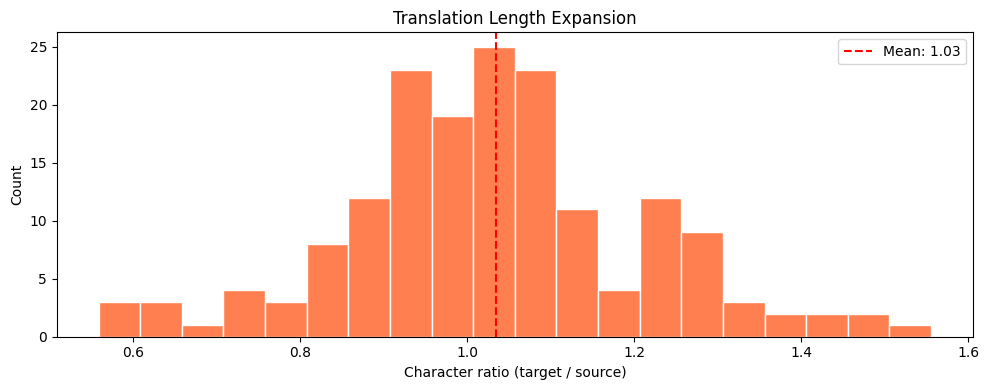

Mean ratio:   1.03
Median ratio: 1.03
Max ratio:    1.56


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json

videos = [{"title": "Strait of Hormuz disruption threatens to shake global economy"}]

# Load source and target transcripts
transcription_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
translation_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

title = videos[0]["title"]
en_data = json.loads((transcription_dir / f"{title}.json").read_text())
es_data = json.loads((translation_dir / f"{title}.json").read_text())

en_segs = en_data["segments"]
es_segs = es_data["segments"]

# Compute char_ratio = len(es_text) / len(en_text) for each segment
ratios = [len(es["text"]) / max(len(en["text"]), 1) for en, es in zip(en_segs, es_segs)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ratios, bins=20, color="coral", edgecolor="white")
ax.axvline(np.mean(ratios), color="red", linestyle="--", label=f"Mean: {np.mean(ratios):.2f}")
ax.set_xlabel("Character ratio (target / source)")
ax.set_ylabel("Count")
ax.set_title("Translation Length Expansion")
ax.legend()
fig.tight_layout()
fig.savefig(str(IMAGES_DIR / "translation_length_ratio.png"), dpi=150)
plt.show()

print(f"Mean ratio:   {np.mean(ratios):.2f}")
print(f"Median ratio: {np.median(ratios):.2f}")
print(f"Max ratio:    {np.max(ratios):.2f}")

## Duration-Aware Re-ranking (Student Assignment)

This corresponds to **P8** in the full pipeline notebook.

The function `get_shorter_translations()` in `foreign_whispers/reranking.py` is a **stub**
that currently returns an empty list. Students implement it to produce shorter
target-language translations that fit within a TTS duration budget.

See the docstring in `reranking.py` for the full specification, including:
- Input/output contract
- Duration heuristic (~15 chars/second for Romance languages)
- Suggested implementation approaches (rule-based, multi-backend, LLM, hybrid)

In [3]:
from foreign_whispers import get_shorter_translations, TranslationCandidate

# Demo the stub: pick a segment and request shorter translations
source_text = en_segs[0]["text"].strip()
baseline_es = es_segs[0]["text"].strip()
target_duration_s = 3.0

print(f"Source (EN):    {source_text}")
print(f"Baseline (ES):  {baseline_es}")
print(f"Duration budget: {target_duration_s}s (~{int(target_duration_s * 15)} chars at 15 chars/s)")
print()

candidates = get_shorter_translations(
    source_text=source_text,
    baseline_es=baseline_es,
    target_duration_s=target_duration_s,
)

print(f"Candidates returned: {len(candidates)}")
if candidates:
    for c in candidates:
        print(f"  [{c.char_count} chars] {c.text}  -- {c.brevity_rationale}")
else:
    print("  (empty list -- stub not yet implemented)")

Source (EN):    60 Minutes overtime.
Baseline (ES):  60 minutos horas extra.
Duration budget: 3.0s (~45 chars at 15 chars/s)

Candidates returned: 0
  (empty list -- stub not yet implemented)


In [6]:
for i, (en, es) in enumerate(zip(en_segs, es_segs)):
    duration = en["end"] - en["start"]
    budget = int(duration * 15)
    es_text = es["text"].strip()
    print(f"seg {i}: budget={budget}, es_len={len(es_text)}, ratio={len(es_text)/max(budget,1):.2f} | {es_text[:40]}")

seg 0: budget=56, es_len=23, ratio=0.41 | 60 minutos horas extra.
seg 1: budget=56, es_len=27, ratio=0.48 | ¿Cuál es el peor escenario?
seg 2: budget=66, es_len=19, ratio=0.29 | Te preocupa que sea
seg 3: budget=82, es_len=43, ratio=0.52 | cerrado durante semanas y semanas y sema
seg 4: budget=87, es_len=25, ratio=0.29 | y empiezas a ver el mundo
seg 5: budget=73, es_len=38, ratio=0.52 | la economía realmente impactada porque
seg 6: budget=68, es_len=32, ratio=0.47 | es la sangre de la vida a cierto
seg 7: budget=58, es_len=43, ratio=0.74 | extensión. Así que la realidad es más la
seg 8: budget=57, es_len=35, ratio=0.61 | que esto continúa, el mayor impacto
seg 9: budget=70, es_len=34, ratio=0.49 | va a tener a través de industrias,
seg 10: budget=71, es_len=49, ratio=0.69 | en todas las regiones. Esta semana en 60
seg 11: budget=68, es_len=39, ratio=0.57 | informamos sobre la Straight of Hormuz,
seg 12: budget=67, es_len=34, ratio=0.51 | esa vía estrecha en el sur de Irán
seg 13: budg

## Summary

- Translation outputs are stored in `pipeline_data/api/translations/argos/`
- The segment format is preserved from the transcription stage, with the `text` field replaced by the translated text
- argostranslate produces unconstrained translations -- no duration budget is enforced
- Romance languages (e.g., Spanish) typically expand text length by ~10-30% vs. English
- The `get_shorter_translations()` stub in `foreign_whispers/reranking.py` is the extension point for duration-aware re-ranking